# 04 — Heston: stochastic volatility

Black-Scholes assumes constant volatility; markets disagree — index options trade on a
persistent **skew**. Heston (1993) makes variance itself a mean-reverting CIR process,
correlated with the spot:

$$dS = (r - q)\,S\,dt + \sqrt{v}\,S\,dW^S, \qquad
dv = \kappa(\theta - v)\,dt + \xi\sqrt{v}\,dW^v, \qquad
d\langle W^S, W^v\rangle = \rho\,dt.$$

$\rho < 0$ (spot down, vol up — the leverage effect) generates the skew;
$\xi$ (vol-of-vol) generates smile convexity. The model stays tractable because its
characteristic function is known in closed form — implemented here in the numerically stable
**"Little Heston Trap"** formulation (Albrecher et al. 2007), priced two independent ways:

- **Gil-Pelaez** inversion, $P_j = \tfrac{1}{2} + \tfrac{1}{\pi}\int_0^\infty
  \mathrm{Re}\big[e^{-iu\ln K}\varphi_j(u)/(iu)\big]\,du$ — pointwise, adaptive quadrature;
- **Carr-Madan FFT** — the whole strike grid in one transform.

Phase 4 pinned this implementation against QuantLib's `AnalyticHestonEngine` on 89 reference
prices: max deviation **1.6e-8**.

In [1]:
import sys
import time
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)

from src.engines import MonteCarloEngine
from src.models import BlackScholesModel, HestonModel

S0, r, q = 100.0, 0.03, 0.0
heston = HestonModel(v0=0.04, kappa=2.0, theta=0.04, xi=0.5, rho=-0.7)

c = float(heston.price(S0, 100.0, 1.0, r, 'call'))
p = float(heston.price(S0, 100.0, 1.0, r, 'put'))
print(f"ATM 1y call {c:.6f} / put {p:.6f}")
print(f"parity gap: {abs(c - p - S0 + 100.0 * np.exp(-r)):.2e}")

# Two independent pricers, one answer
strikes = np.arange(70.0, 131.0, 5.0)
fft_prices = heston.price_surface(S0, strikes, 1.0, r)
gp_prices = np.array([float(heston.price(S0, float(K), 1.0, r, 'call')) for K in strikes])
print(f"max |FFT - Gil-Pelaez| over {len(strikes)} strikes: {np.abs(fft_prices - gp_prices).max():.2e}")
assert np.abs(fft_prices - gp_prices).max() < 1e-6

ATM 1y call 8.929410 / put 5.973964
parity gap: 0.00e+00
max |FFT - Gil-Pelaez| over 13 strikes: 2.40e-07


C:\Users\Miguel Rey\AppData\Local\Temp\ipykernel_11080\390099199.py:17: UserWarning: Feller condition violated: 2*kappa*theta = 0.160000 < xi^2 = 0.250000. The variance process can reach zero. This is common in equity calibrations and handled correctly by both the characteristic function and the QE simulation scheme; informative, not an error.
  heston = HestonModel(v0=0.04, kappa=2.0, theta=0.04, xi=0.5, rho=-0.7)


**Sanity limit:** as $\xi \to 0$ with $v_0 = \theta$, variance is frozen and Heston must
collapse to Black-Scholes with $\sigma = \sqrt{v_0}$.

In [2]:
frozen = HestonModel(v0=0.04, kappa=2.0, theta=0.04, xi=1e-4, rho=0.0)
bs_ref = BlackScholesModel(sigma=0.20)
diff = abs(float(frozen.price(S0, 100.0, 1.0, r, 'call')) - float(bs_ref.price(S0, 100.0, 1.0, r, 'call')))
print(f"|Heston(xi->0) - BS(sigma=0.20)| = {diff:.2e}")
assert diff < 1e-6

|Heston(xi->0) - BS(sigma=0.20)| = 2.82e-08


## Simulation: the QE scheme

Euler on the CIR variance produces $v < 0$ (and $\sqrt{v}$ dies) with nonzero probability.
Andersen's (2008) **Quadratic-Exponential** scheme instead samples the variance transition
from a distribution matched to its *exact* conditional moments, with an exponential branch
that puts genuine probability mass at $v = 0$ — essential because our parameters violate the
Feller condition ($2\kappa\theta = 0.16 < \xi^2 = 0.25$), as real calibrations routinely do.
The martingale correction (Andersen §4.3.3) is on by default; we verify
$\mathbb{E}[e^{-rT} S_T] = S_0$ within Monte Carlo noise.

martingale z-score: -2.02
paths whose variance hits exactly zero: 31.0%


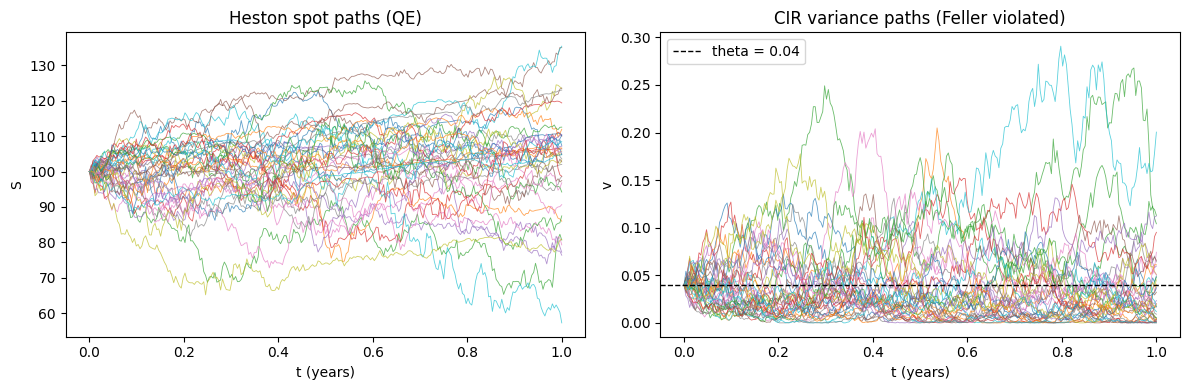

In [3]:
engine = MonteCarloEngine(n_paths=100_000, n_steps=252, seed=42)
spot_paths, var_paths = engine.simulate_heston(
    S0, 0.04, 1.0, r, kappa=2.0, theta=0.04, xi=0.5, rho=-0.7, return_variance=True
)

# Martingale check on the discounted terminal spot
disc_ST = np.exp(-r * 1.0) * spot_paths[:, -1]
z_mart = (disc_ST.mean() - S0) / (disc_ST.std(ddof=1) / np.sqrt(len(disc_ST)))
touched_zero = float((var_paths == 0.0).any(axis=1).mean())
print(f"martingale z-score: {z_mart:+.2f}")
print(f"paths whose variance hits exactly zero: {100 * touched_zero:.1f}%")
assert abs(z_mart) < 3

t_grid = np.linspace(0.0, 1.0, var_paths.shape[1])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(t_grid, spot_paths[:40].T, lw=0.6, alpha=0.7)
axes[0].set(title='Heston spot paths (QE)', xlabel='t (years)', ylabel='S')
axes[1].plot(t_grid, var_paths[:40].T, lw=0.6, alpha=0.7)
axes[1].axhline(0.04, color='k', ls='--', lw=1, label='theta = 0.04')
axes[1].set(title='CIR variance paths (Feller violated)', xlabel='t (years)', ylabel='v')
axes[1].legend()
fig.tight_layout()

## The smile

Price European options across strikes, invert each through the Phase 1 Black-Scholes solver
(OTM side, market convention) — a single Heston parameter set produces the whole smile
family. Short maturities show the steepest skew; mean reversion flattens the long end.

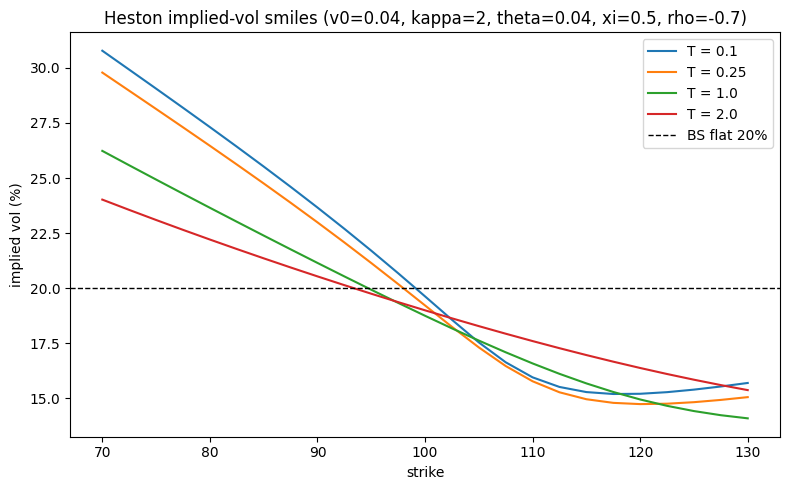

In [4]:
def heston_iv(model, K_arr, T_, r_, q_=0.0):
    ivs = []
    for K_ in np.atleast_1d(K_arr):
        opt = 'put' if K_ < S0 else 'call'
        price_ = float(model.price(S0, float(K_), T_, r_, opt, q=q_))
        ivs.append(BlackScholesModel.implied_vol(price_, S0, float(K_), T_, r_, opt, q=q_))
    return np.array(ivs)

K_grid = np.arange(70.0, 131.0, 2.5)
fig, ax = plt.subplots(figsize=(8, 5))
for T_ in (0.1, 0.25, 1.0, 2.0):
    ax.plot(K_grid, 100 * heston_iv(heston, K_grid, T_, r), label=f'T = {T_}')
ax.axhline(20.0, color='k', ls='--', lw=1, label='BS flat 20%')
ax.set(title='Heston implied-vol smiles (v0=0.04, kappa=2, theta=0.04, xi=0.5, rho=-0.7)',
       xlabel='strike', ylabel='implied vol (%)')
ax.legend()
fig.tight_layout()

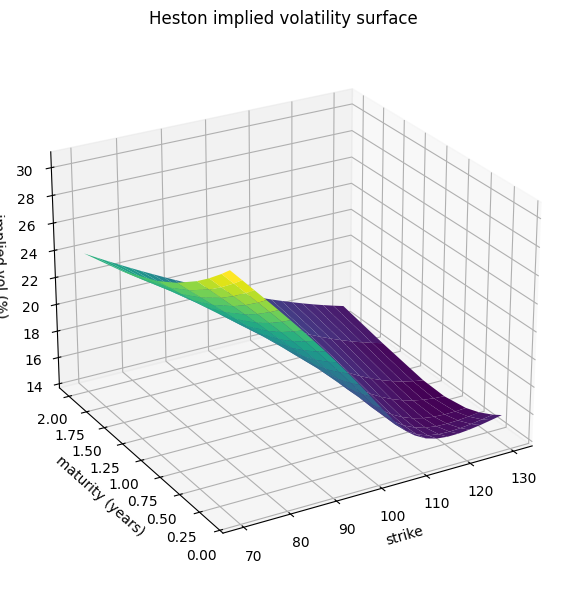

In [5]:
from matplotlib import cm

T_grid = np.array([0.1, 0.2, 0.35, 0.5, 0.75, 1.0, 1.5, 2.0])
iv_surf = np.array([heston_iv(heston, K_grid, float(T_), r) for T_ in T_grid])

KK, TT = np.meshgrid(K_grid, T_grid)
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(KK, TT, 100 * iv_surf, cmap=cm.viridis, linewidth=0, antialiased=True)
ax.set(xlabel='strike', ylabel='maturity (years)', zlabel='implied vol (%)',
       title='Heston implied volatility surface')
ax.view_init(elev=25, azim=-120)
fig.tight_layout()

img_dir = ROOT / 'docs' / 'img'
img_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(img_dir / 'heston_iv_surface.png', dpi=150, bbox_inches='tight')

## Calibration: a controlled round-trip

The calibrator minimizes **implied-vol-space** residuals with an unconstrained exp/tanh
reparametrization and deterministic multi-start least squares (1 FFT per maturity per
objective evaluation).

The experiment is a *round-trip on synthetic data* — generate a surface from known
parameters, add noise, recover them — because it is fully reproducible offline. The same
calibrator was run on **1,718 real SPX options across 8 expiries in Phase 4: RMSE 1.3 vol
points** (v0=0.033, theta=0.048, rho=-0.64; kappa=13 with xi=3 — the short-dated SPX skew decays
faster than Heston allows, which is the empirical motivation for notebook 05).

$v_0$, $\theta$, $\rho$ pin down easily. $\kappa$ and $\xi$ live on a well-known
identifiability ridge — with only short maturities or heavier noise they trade off against
each other, which is exactly how the real SPX fit landed at $\kappa = 13$, $\xi = 3$. With
five maturities out to 2 years and 0.1 vol points of noise, all five recover:

In [6]:
from src.calibration import HestonCalibrator

true_params = dict(v0=0.035, kappa=1.5, theta=0.05, xi=0.8, rho=-0.65)
true_model = HestonModel(**true_params)

K_cal = np.arange(75.0, 126.0, 5.0)
T_cal = np.array([0.1, 0.25, 0.5, 1.0, 2.0])
Ks, Ts, ivs = [], [], []
for T_ in T_cal:
    iv_row = heston_iv(true_model, K_cal, float(T_), r)
    Ks.extend(K_cal); Ts.extend([float(T_)] * len(K_cal)); ivs.extend(iv_row)

rng = np.random.default_rng(0)
noise_sd = 0.0010  # 0.10 vol points
ivs_market = np.array(ivs) + rng.normal(0.0, noise_sd, len(ivs))

cal = HestonCalibrator(S0=S0, r=r, q=q)
t0 = time.perf_counter()
fit = cal.calibrate(np.array(Ks), np.array(Ts), ivs_market)
print(f"calibrated in {time.perf_counter() - t0:.1f}s  (success={fit.success})")

print(f"\n{'param':>7} {'true':>8} {'recovered':>10}")
for k_ in ('v0', 'kappa', 'theta', 'xi', 'rho'):
    print(f"{k_:>7} {true_params[k_]:>8.4f} {fit.params[k_]:>10.4f}")
print(f"\nrmse_iv = {100 * fit.rmse_iv:.3f} vol pts  (noise injected: {100 * noise_sd:.2f})")
assert fit.rmse_iv < 3 * noise_sd
assert abs(fit.params['rho'] - true_params['rho']) < 0.10
assert abs(np.sqrt(fit.params['v0']) - np.sqrt(true_params['v0'])) < 0.01

C:\Users\Miguel Rey\AppData\Local\Temp\ipykernel_11080\937039622.py:4: UserWarning: Feller condition violated: 2*kappa*theta = 0.150000 < xi^2 = 0.640000. The variance process can reach zero. This is common in equity calibrations and handled correctly by both the characteristic function and the QE simulation scheme; informative, not an error.
  true_model = HestonModel(**true_params)


calibrated in 0.8s  (success=True)

  param     true  recovered
     v0   0.0350     0.0349
  kappa   1.5000     1.4582
  theta   0.0500     0.0508
     xi   0.8000     0.7967
    rho  -0.6500    -0.6491

rmse_iv = 0.087 vol pts  (noise injected: 0.10)


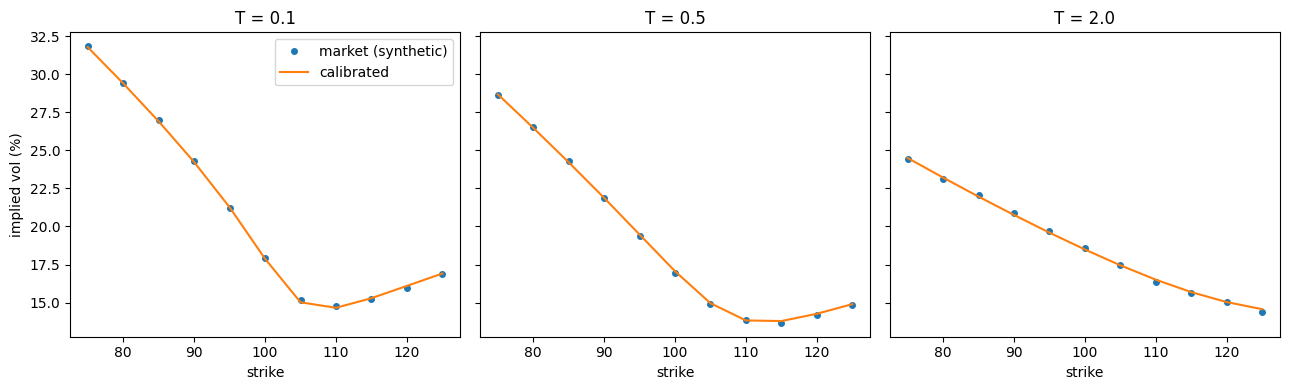

In [7]:
# Fit quality, seen as smiles: market dots vs calibrated model lines
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, T_ in zip(axes, (0.1, 0.5, 2.0)):
    mask = np.isclose(np.array(Ts), T_)
    ax.plot(np.array(Ks)[mask], 100 * ivs_market[mask], 'o', ms=4, label='market (synthetic)')
    ax.plot(K_cal, 100 * heston_iv(fit.model, K_cal, float(T_), r), '-', label='calibrated')
    ax.set(title=f'T = {T_}', xlabel='strike')
axes[0].set_ylabel('implied vol (%)')
axes[0].legend()
fig.tight_layout()

## Exotics under stochastic volatility — zero code changes

The Phase 3 instruments only see `paths`; whether those came from GBM or Heston is irrelevant
to them. Comparison at **matched ATM 1y implied vol**, so any difference is pure smile
effect, not a vol-level artifact. The Asian barely moves — averaging is essentially an
ATM-variance trade. The up-and-out call is a different story: with $\rho = -0.7$ the skew
*suppresses* upside volatility, rallies happen on falling vol, the barrier at 130 is hit far
less often, and the knock-out is worth dramatically more than under flat-vol GBM. Barrier
risk lives in the **wing** vol, not the ATM vol — the classic reason flat-vol barrier quotes
are wrong.

In [8]:
from src.instruments import AsianOption, BarrierOption

sigma_atm = float(heston_iv(heston, np.array([100.0]), 1.0, r)[0])
gbm_paths = engine.simulate_gbm(S0, 1.0, r, sigma_atm)

asian = AsianOption(K=100.0, option_type='call')
barrier = BarrierOption(K=100.0, barrier=130.0, barrier_type='up-and-out', option_type='call')

print(f"matched GBM vol: {100 * sigma_atm:.2f}%  |  100k paths, 252 steps, same seed\n")
print(f"{'instrument':>18} {'GBM':>9} {'Heston':>9} {'diff/SE':>8}")
for name, inst in (('Asian call', asian), ('up-and-out call', barrier)):
    r_gbm = engine.price(inst.payoff, gbm_paths, r, 1.0)
    r_hes = engine.price(inst.payoff, spot_paths, r, 1.0)
    se = np.hypot(r_gbm.std_error, r_hes.std_error)
    print(f"{name:>18} {r_gbm.price:>9.4f} {r_hes.price:>9.4f} {(r_hes.price - r_gbm.price) / se:>+8.1f}")

matched GBM vol: 18.75%  |  100k paths, 252 steps, same seed

        instrument       GBM    Heston  diff/SE
        Asian call    5.0373    5.0684     +1.0
   up-and-out call    3.7258    6.5728    +87.1


---
**Next:** [05 — Rough Bergomi](05_rough_bergomi_skew.ipynb) — what Heston structurally cannot
do: the short-dated skew power law $\psi(T) \sim T^{H - 1/2}$.